In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# Data from the table in your screenshot
X = np.array([
    [ 1,  2],
    [ 3,  3],
    [ 2,  2],
    [ 8,  8],
    [ 6,  6],
    [ 7,  7],
    [-3, -3],
    [-2, -4],
    [-7, -7]
], dtype=float)

N, D = X.shape
N, D

(9, 2)

In [2]:
def gaussian_diag_pdf(X, mu, var):
    """
    X: (N,D)
    mu: (D,)
    var: (D,) diagonal variances (must be >0)
    returns: (N,) pdf values
    """
    eps = 1e-12
    var = np.maximum(var, eps)
    diff = X - mu
    # log pdf for diagonal Gaussian
    logp = -0.5 * (D * np.log(2*np.pi) + np.sum(np.log(var)) + np.sum((diff**2)/var, axis=1))
    return np.exp(logp)

def e_step(X, pis, mus, vars_):
    """
    returns responsibilities W: (N,K)
    W[n,j] = p(x_n | j) * pi_j / sum_l p(x_n|l)*pi_l
    """
    N = X.shape[0]
    K = len(pis)
    numer = np.zeros((N, K))
    for j in range(K):
        numer[:, j] = pis[j] * gaussian_diag_pdf(X, mus[j], vars_[j])
    denom = np.sum(numer, axis=1, keepdims=True)
    W = numer / np.maximum(denom, 1e-300)
    return W

def m_step(X, W):
    """
    Updates pi, mu, var using:
      pi_j = (1/N) sum_n w_nj
      mu_j = sum_n w_nj x_n / sum_n w_nj
      var_j (diag) = sum_n w_nj (x_n - mu_j)^2 / sum_n w_nj
    """
    N, D = X.shape
    K = W.shape[1]
    Nk = np.sum(W, axis=0)  # (K,)
    pis = Nk / N
    mus = np.zeros((K, D))
    vars_ = np.zeros((K, D))
    for j in range(K):
        if Nk[j] < 1e-12:
            # dead component: keep something safe
            mus[j] = np.mean(X, axis=0)
            vars_[j] = np.var(X, axis=0) + 1e-6
        else:
            mus[j] = (W[:, j:j+1] * X).sum(axis=0) / Nk[j]
            diff = X - mus[j]
            vars_[j] = (W[:, j:j+1] * (diff**2)).sum(axis=0) / Nk[j]
            vars_[j] = np.maximum(vars_[j], 1e-6)
    return pis, mus, vars_

def log_likelihood(X, pis, mus, vars_):
    """
    log p(X) = sum_n log sum_j pi_j N(x_n | mu_j, var_j)
    """
    N = X.shape[0]
    K = len(pis)
    comp = np.zeros((N, K))
    for j in range(K):
        comp[:, j] = pis[j] * gaussian_diag_pdf(X, mus[j], vars_[j])
    s = np.sum(comp, axis=1)
    return np.sum(np.log(np.maximum(s, 1e-300)))

def run_em(X, init_pis, init_mus, init_vars, iters=3, verbose=True):
    pis = init_pis.copy()
    mus = init_mus.copy()
    vars_ = init_vars.copy()

    lls = []
    lls.append(log_likelihood(X, pis, mus, vars_))

    for t in range(1, iters+1):
        W = e_step(X, pis, mus, vars_)
        pis, mus, vars_ = m_step(X, W)
        ll = log_likelihood(X, pis, mus, vars_)
        lls.append(ll)

        if verbose:
            print(f"\n=== Iteration {t} ===")
            print("w (responsibilities) shape:", W.shape)
            print(W)
            print("\nmixture weights pi:", pis)
            print("means mu:\n", mus)
            print("diag variances:\n", vars_)
            print("log-likelihood:", ll)

    return pis, mus, vars_, W, np.array(lls)

In [3]:
K = 3
init_mus = np.array([[3,3], [2,2], [-3,-3]], dtype=float)
init_vars = np.ones((K, D), dtype=float)          # identity covariance => diag var = 1
init_pis = np.ones(K, dtype=float) / K           # equal weights

pis3, mus3, vars3, W3, lls3 = run_em(X, init_pis, init_mus, init_vars, iters=3, verbose=True)


=== Iteration 1 ===
w (responsibilities) shape: (9, 3)
[[0.1192 0.8808 0.    ]
 [0.7311 0.2689 0.    ]
 [0.2689 0.7311 0.    ]
 [1.     0.     0.    ]
 [0.9991 0.0009 0.    ]
 [0.9999 0.0001 0.    ]
 [0.     0.     1.    ]
 [0.     0.     1.    ]
 [0.     0.     1.    ]]

mixture weights pi: [0.4576 0.2091 0.3333]
means mu:
 [[ 5.7899  5.8189]
 [ 1.6772  2.1452]
 [-4.     -4.6667]]
diag variances:
 [[4.5362 4.287 ]
 [0.5165 0.1315]
 [4.6667 2.8889]]
log-likelihood: -39.72599315621764

=== Iteration 2 ===
w (responsibilities) shape: (9, 3)
[[0.0032 0.9968 0.    ]
 [0.6551 0.3449 0.    ]
 [0.0058 0.9942 0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]
 [0.     0.     1.    ]
 [0.     0.     1.    ]
 [0.     0.     1.    ]]

mixture weights pi: [0.4071 0.2595 0.3333]
means mu:
 [[ 6.2718  6.2726]
 [ 1.7209  2.1476]
 [-4.     -4.6666]]
diag variances:
 [[2.9467 2.9385]
 [0.4965 0.1258]
 [4.6667 2.889 ]]
log-likelihood: -38.80573198057705

=== Iteration 3 ===

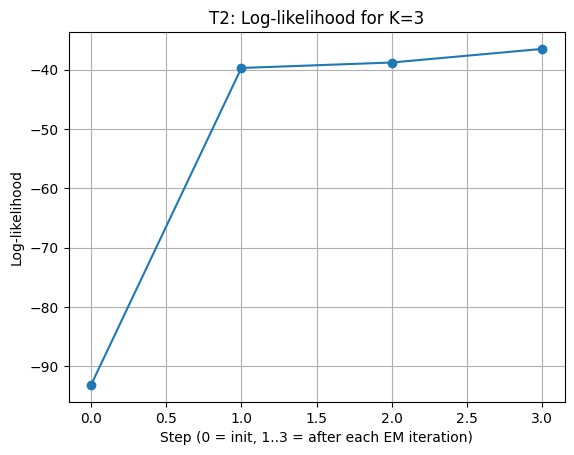

array([-93.1739, -39.726 , -38.8057, -36.513 ])

In [4]:
plt.figure()
plt.plot(range(len(lls3)), lls3, marker='o')
plt.xlabel("Step (0 = init, 1..3 = after each EM iteration)")
plt.ylabel("Log-likelihood")
plt.title("T2: Log-likelihood for K=3")
plt.grid(True)
plt.show()

lls3

In [5]:
K = 2
init_mus = np.array([[3,3], [-3,-3]], dtype=float)
init_vars = np.ones((K, D), dtype=float)
init_pis = np.ones(K, dtype=float) / K

pis2, mus2, vars2, W2, lls2 = run_em(X, init_pis, init_mus, init_vars, iters=3, verbose=True)


=== Iteration 1 ===
w (responsibilities) shape: (9, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

mixture weights pi: [0.6667 0.3333]
means mu:
 [[ 4.5     4.6667]
 [-4.     -4.6667]]
diag variances:
 [[6.9167 5.8889]
 [4.6667 2.8889]]
log-likelihood: -46.291961062950485

=== Iteration 2 ===
w (responsibilities) shape: (9, 2)
[[0.9999 0.0001]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [0.0002 0.9998]
 [0.0002 0.9998]
 [0.     1.    ]]

mixture weights pi: [0.6667 0.3333]
means mu:
 [[ 4.4996  4.6662]
 [-3.9999 -4.6665]]
diag variances:
 [[6.9194 5.8928]
 [4.6681 2.891 ]]
log-likelihood: -46.29195948129465

=== Iteration 3 ===
w (responsibilities) shape: (9, 2)
[[0.9999 0.0001]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [1.     0.    ]
 [0.0002 0.9998]
 [0.0002 0.9998]
 [0.     1.    ]]

mixture weights pi: [0.6667 0.3333]
means mu:
 [[ 4.4996  4.6662]
 [-3.9999 -4.6665]]
diag v

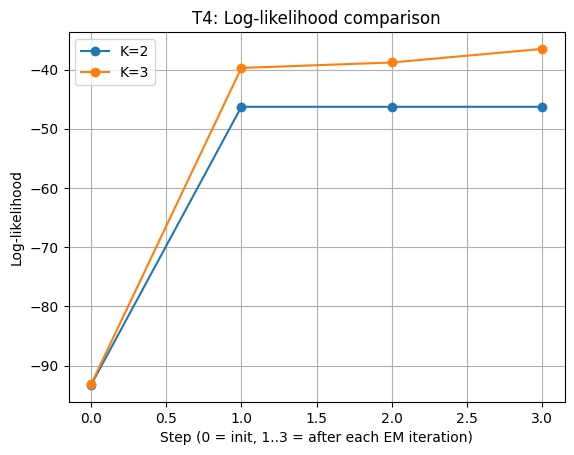

Final LL (K=2): -46.291959481240255
Final LL (K=3): -36.512976311414356


In [6]:
plt.figure()
plt.plot(range(len(lls2)), lls2, marker='o', label="K=2")
plt.plot(range(len(lls3)), lls3, marker='o', label="K=3")
plt.xlabel("Step (0 = init, 1..3 = after each EM iteration)")
plt.ylabel("Log-likelihood")
plt.title("T4: Log-likelihood comparison")
plt.grid(True)
plt.legend()
plt.show()

print("Final LL (K=2):", lls2[-1])
print("Final LL (K=3):", lls3[-1])


=== Iteration 1 ===
w (responsibilities) shape: (9, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

mixture weights pi: [1. 0.]
means mu:
 [[1.6667 1.5556]
 [1.6667 1.5556]]
diag variances:
 [[22.2222 24.2469]
 [22.2222 24.2469]]
log-likelihood: -53.84311315322616

=== Iteration 2 ===
w (responsibilities) shape: (9, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

mixture weights pi: [1. 0.]
means mu:
 [[1.6667 1.5556]
 [1.6667 1.5556]]
diag variances:
 [[22.2222 24.2469]
 [22.2222 24.2469]]
log-likelihood: -53.84311315322616

=== Iteration 3 ===
w (responsibilities) shape: (9, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

mixture weights pi: [1. 0.]
means mu:
 [[1.6667 1.5556]
 [1.6667 1.5556]]
diag variances:
 [[22.2222 24.2469]
 [22.2222 24.2469]]
log-likelihood: -53.84311315322616


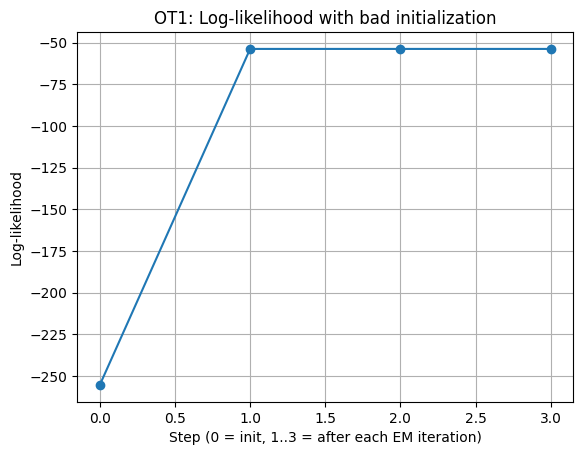

Final mixture weights: [1. 0.]
Final means:
 [[1.6667 1.5556]
 [1.6667 1.5556]]


In [7]:
K = 2
init_mus = np.array([[0,0], [10000,10000]], dtype=float)
init_vars = np.ones((K, D), dtype=float)
init_pis = np.ones(K, dtype=float) / K

pis_bad, mus_bad, vars_bad, W_bad, lls_bad = run_em(X, init_pis, init_mus, init_vars, iters=3, verbose=True)

plt.figure()
plt.plot(range(len(lls_bad)), lls_bad, marker='o')
plt.xlabel("Step (0 = init, 1..3 = after each EM iteration)")
plt.ylabel("Log-likelihood")
plt.title("OT1: Log-likelihood with bad initialization")
plt.grid(True)
plt.show()

print("Final mixture weights:", pis_bad)
print("Final means:\n", mus_bad)